In [1]:
import lightcurve
from lightcurve import generate_snia_lightcurve, generate_custom_model, fixed_param, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, make_visibility_row, determine_visibility

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
from lightcurve import limit_mag_dict, snia_lightcurve_params
snia_lightcurve_params

['redshift', 'x1', 'c', 't0', 'magabs', 'ra', 'dec']

In [3]:
import numpy as np
from matplotlib import pyplot as plt

In [4]:
lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]

### Generate fixed parameters

{'redshift': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': 0.01}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': 0.04}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': 0.36}, 'as': 'c'}, 'magabs': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': -18.523}, 'as': 'magabs'}, 'radec': {'func': <function fixed_radec at 0x73bd545b3530>, 'kwargs': {'size': 1, 'ra': 104, 'dec': -33}, 'as': ['ra', 'dec']}} <class 'dict'>
Skipping lsstz: outside model range.
Skipping lssty: outside model range.
valid bands are: ['lsstu', 'lsstg', 'lsstr', 'lssti']


/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)


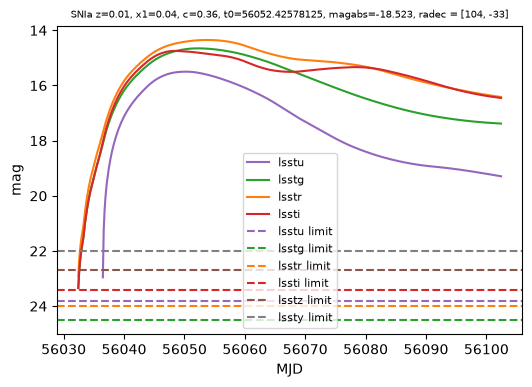

{'redshift': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': 0.1}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': 0.04}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': 0.36}, 'as': 'c'}, 'magabs': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': -18.523}, 'as': 'magabs'}, 'radec': {'func': <function fixed_radec at 0x73bd545b3530>, 'kwargs': {'size': 1, 'ra': 104, 'dec': -33}, 'as': ['ra', 'dec']}} <class 'dict'>
Skipping lssty: outside model range.
valid bands are: ['lsstu', 'lsstg', 'lsstr', 'lssti', 'lsstz']


/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)


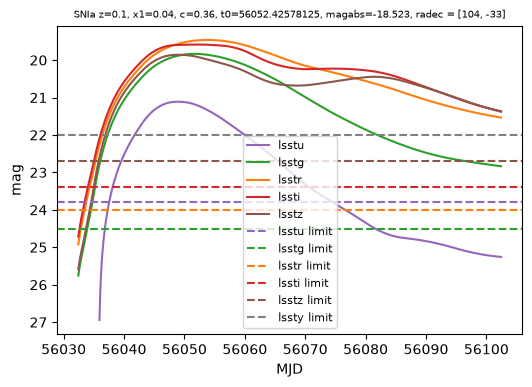

{'redshift': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': 0.5}, 'as': 'z'}, 'x1': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': 0.04}, 'as': 'x1'}, 'c': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': 0.36}, 'as': 'c'}, 'magabs': {'func': <function fixed_param at 0x73bde80ef8a0>, 'kwargs': {'size': 1, 'value': -18.523}, 'as': 'magabs'}, 'radec': {'func': <function fixed_radec at 0x73bd545b3530>, 'kwargs': {'size': 1, 'ra': 104, 'dec': -33}, 'as': ['ra', 'dec']}} <class 'dict'>
valid bands are: ['lsstu', 'lsstg', 'lsstr', 'lssti', 'lsstz', 'lssty']


/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)


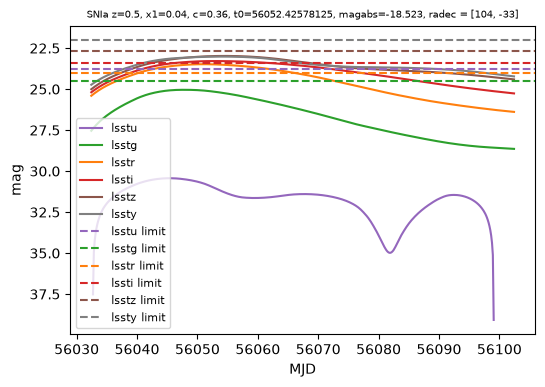

In [47]:
snia_models = []
data_models = []
for redshift in [0.01, 0.1, 0.5]:
    #keep the other params fixed
    snia_dict = None #initiate with None
    snia_dict = generate_snia_dict(ra = 104, dec = -33, redshift=redshift, x1 = 0.04, magabs = -18.523, c = 0.36)
    snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
    snia_model, model_data = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, plot_curve = True, return_values = True, return_models = True)
    snia_models.append(snia_model)
    data_models.append(model_data)

In [ ]:
# input data points at every cadence.
# include a survey which gives you data points within this lc based on the pos in the sky
# and whether the obs

In [32]:
len(data_models)
visibility = determine_visibility(data_models[2])
visibility



,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,0,0,1,1,0,0


In [ ]:
data_models[0]['times']
data_models[0]['lc_by_band']

{'times': array([56032.42578125, 56032.56606181, 56032.70634237, 56032.84662293,
        56032.98690349, 56033.12718406, 56033.26746462, 56033.40774518,
        56033.54802574, 56033.6883063 , 56033.82858686, 56033.96886742,
        56034.10914798, 56034.24942854, 56034.38970911, 56034.52998967,
        56034.67027023, 56034.81055079, 56034.95083135, 56035.09111191,
        56035.23139247, 56035.37167303, 56035.51195359, 56035.65223416,
        56035.79251472, 56035.93279528, 56036.07307584, 56036.2133564 ,
        56036.35363696, 56036.49391752, 56036.63419808, 56036.77447864,
        56036.91475921, 56037.05503977, 56037.19532033, 56037.33560089,
        56037.47588145, 56037.61616201, 56037.75644257, 56037.89672313,
        56038.03700369, 56038.17728426, 56038.31756482, 56038.45784538,
        56038.59812594, 56038.7384065 , 56038.87868706, 56039.01896762,
        56039.15924818, 56039.29952874, 56039.43980931, 56039.58008987,
        56039.72037043, 56039.86065099, 56040.00093155,

In [ ]:
import pandas as pd
rows = []
# model is the skysurvey.core.target.Target, data is the y data
for model, data in zip(snia_models, data_models):
    vis = determine_visibility(data, return_dict = True) #this makes a dict
    row = {**{k: data[k] for k in snia_lightcurve_params}, **vis}
    rows.append(row)

df = pd.DataFrame(
    rows,
    index=[f"model_{i}" for i in range(len(data_models))],
    columns=snia_lightcurve_params + bands
)

df

,redshift,x1,c,t0,magabs,ra,dec,lsstu,lsstg,lsstr,lssti,lsstz,lssty
model_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,-1,-1
model_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,1,-1
model_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,1,0,0


In [ ]:

stacked_df = pd.DataFrame()
ser = pd.Series(int(np.arange(0, len(data_models))), index=[f"{i}" for i in range(len(data_models))], columns = snia_lightcurve_params + bands)
df = pd.DataFrame(data=ser, index=["a", "c"])


TypeError: only 0-dimensional arrays can be converted to Python scalars